In [1]:
# Imports
import os
import json
import copy
import math
from collections import Counter, defaultdict
from typing import List, Tuple, Optional
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import AdamW
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset, random_split
import torchvision.transforms as T
from torchvision import datasets
from torchvision.transforms import autoaugment, functional as TF

import timm
from timm.models.vision_transformer import VisionTransformer
from timm.scheduler import CosineLRScheduler

from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support
)
from dataclasses import dataclass
from torchvision.utils import save_image
import random





In [2]:
class AffectNetClassificationDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, transform=None):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.transform = transform
        self.annotations = {}

        # Add tqdm progress bar here
        annotation_files = [file for file in os.listdir(annotation_dir) if file.endswith('.npy')]
        for file in tqdm(annotation_files, desc="Loading AffectNet annotation files"):
            key = file.split('.')[0]
            npy_path = os.path.join(annotation_dir, file)
            self.annotations[key] = np.load(npy_path, allow_pickle=True)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        img_id = os.path.splitext(img_name)[0]
        aro = self.annotations.get(f'{img_id}_aro', np.array([-1]))
        val = self.annotations.get(f'{img_id}_val', np.array([-1]))
        exp = self.annotations.get(f'{img_id}_exp', np.array([-1]))
        aro = aro.item() if aro.size == 1 else aro
        val = val.item() if val.size == 1 else val
        exp = exp.item() if exp.size == 1 else exp

        labels = {
            'arousal': aro,
            'valence': val,
            'expression': exp
        }

        return image, labels

In [3]:
train_image_dir = "../datasets/AffectNet/AffectNet-images/train_set/images"
val_image_dir = "../datasets/AffectNet/AffectNet-images/val_set/images"
train_ds = torch.load("../datasets/AffectNet/AffectNet-torch/train_dataset.pt", weights_only=False)
val_ds = torch.load("../datasets/AffectNet/AffectNet-torch/test_dataset.pt", weights_only=False)
train_ds.image_dir = train_image_dir
val_ds.image_dir = val_image_dir    

In [4]:

# Style
plt.style.use("seaborn-v0_8-whitegrid")
random.seed(42)
np.random.seed(42)

# Output directory (current working directory)
OUTPUT_DIR = os.getcwd()
print(f"Plots will be saved to: {OUTPUT_DIR}")


Plots will be saved to: /home/ichalalentarek/Desktop/Deep Learning/code


In [5]:
import math
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

EMOTION_NAMES = {
    0: "Neutral",
    1: "Happy",
    2: "Sad",
    3: "Surprise",
    4: "Fear",
    5: "Disgust",
    6: "Anger",
    7: "Contempt",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}


def save_figure(fig, filename: str):
    fig.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def _to_scalar(value):
    if value is None:
        return None
    try:
        # numpy scalar
        if hasattr(value, "item"):
            value = value.item()
    except Exception:
        pass
    return value


def _is_valid_number(x):
    if x is None:
        return False
    try:
        xf = float(x)
        if not math.isfinite(xf):
            return False
        return True
    except Exception:
        return False


def extract_labels_from_annotations(ds) -> Dict[str, List]:
    if not hasattr(ds, "annotations") or not isinstance(ds.annotations, dict) or len(ds.annotations) == 0:
        return {"valences": [], "arousals": [], "expressions": [], "va_pairs": []}

    per_id: Dict[str, Dict[str, float]] = defaultdict(dict)

    for key, value in ds.annotations.items():
        if not isinstance(key, str):
            continue
        base, suffix = key.rsplit("_", 1) if "_" in key else (key, "")
        val = _to_scalar(value)
        if suffix in {"val", "aro", "exp"}:
            per_id[base][suffix] = val

    valences, arousals, expressions, va_pairs = [], [], [], []

    for _, lbl in per_id.items():
        v = lbl.get("val", None)
        a = lbl.get("aro", None)
        e = lbl.get("exp", None)

        if _is_valid_number(v):
            valences.append(float(v))
        if _is_valid_number(a):
            arousals.append(float(a))
        if _is_valid_number(v) and _is_valid_number(a):
            va_pairs.append((float(v), float(a)))
        if e is not None:
            try:
                expressions.append(int(e))
            except Exception:
                pass

    return {
        "valences": valences,
        "arousals": arousals,
        "expressions": expressions,
        "va_pairs": va_pairs,
    }


def extract_labels_via_iteration(ds, max_samples: Optional[int] = 5000) -> Dict[str, List]:
    n = len(ds)
    indices = list(range(n))
    if max_samples is not None:
        max_samples = min(max_samples, n)
        indices = random.sample(indices, max_samples)

    valences, arousals, expressions, va_pairs = [], [], [], []

    for idx in tqdm(indices, desc="Iterating dataset for labels"):
        try:
            _, labels = ds[idx]
        except Exception:
            continue

        v = _to_scalar(labels.get("valence")) if isinstance(labels, dict) else None
        a = _to_scalar(labels.get("arousal")) if isinstance(labels, dict) else None
        e = _to_scalar(labels.get("expression")) if isinstance(labels, dict) else None

        if _is_valid_number(v):
            valences.append(float(v))
        if _is_valid_number(a):
            arousals.append(float(a))
        if _is_valid_number(v) and _is_valid_number(a):
            va_pairs.append((float(v), float(a)))
        if e is not None:
            try:
                expressions.append(int(e))
            except Exception:
                pass

    return {
        "valences": valences,
        "arousals": arousals,
        "expressions": expressions,
        "va_pairs": va_pairs,
    }


def extract_labels(ds, max_samples_if_iter: Optional[int] = 5000) -> Dict[str, List]:
    res = extract_labels_from_annotations(ds)
    if any(len(res[k]) > 0 for k in res):
        return res
    return extract_labels_via_iteration(ds, max_samples=max_samples_if_iter)


def analyze_labels(labels: Dict[str, List], split_name: str):
    valences = [x for x in labels.get("valences", []) if _is_valid_number(x) and -1.5 <= float(x) <= 1.5]
    arousals = [x for x in labels.get("arousals", []) if _is_valid_number(x) and -1.5 <= float(x) <= 1.5]
    expressions = [int(x) for x in labels.get("expressions", []) if isinstance(x, (int, np.integer)) and x >= 0]
    va_pairs = [(float(v), float(a)) for (v, a) in labels.get("va_pairs", []) if -1.5 <= float(v) <= 1.5 and -1.5 <= float(a) <= 1.5]

    # Expression distribution (pie chart)
    if len(expressions) > 0:
        counts = Counter(expressions)
        classes = sorted(counts.keys())
        names = [EMOTION_NAMES.get(c, str(c)) for c in classes]
        values = [counts[c] for c in classes]

        fig, ax = plt.subplots(figsize=(6, 6))
        colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))
        wedges, texts, autotexts = ax.pie(
            values,
            labels=names,
            autopct="%1.1f%%",
            startangle=90,
            colors=colors,
            pctdistance=0.75
        )
        ax.axis("equal")
        ax.set_title(f"Expression distribution ({split_name})")
        save_figure(fig, f"expression_distribution_{split_name}.png")

    # Valence histogram
    if len(valences) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(valences, bins=50, color="#F58518", alpha=0.9)
        ax.set_title(f"Valence histogram ({split_name})")
        ax.set_xlabel("Valence")
        ax.set_ylabel("Count")
        ax.set_xlim(-1.1, 1.1)
        save_figure(fig, f"valence_hist_{split_name}.png")

    # Arousal histogram
    if len(arousals) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(arousals, bins=50, color="#54A24B", alpha=0.9)
        ax.set_title(f"Arousal histogram ({split_name})")
        ax.set_xlabel("Arousal")
        ax.set_ylabel("Count")
        ax.set_xlim(-1.1, 1.1)
        save_figure(fig, f"arousal_hist_{split_name}.png")

    # Valence vs Arousal: hexbin and scatter
    if len(va_pairs) > 0:
        va = np.asarray(va_pairs, dtype=float)

        fig, ax = plt.subplots(figsize=(6, 5))
        hb = ax.hexbin(va[:, 0], va[:, 1], gridsize=40, cmap="viridis", mincnt=1, extent=[-1.1, 1.1, -1.1, 1.1])
        ax.set_title(f"Valence vs Arousal (hexbin) ({split_name})")
        ax.set_xlabel("Valence")
        ax.set_ylabel("Arousal")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Count")
        save_figure(fig, f"valence_arousal_hexbin_{split_name}.png")

        # Scatter (sample if very large)
        max_points = 50000
        if va.shape[0] > max_points:
            idx = np.random.choice(va.shape[0], size=max_points, replace=False)
            va_s = va[idx]
        else:
            va_s = va

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(va_s[:, 0], va_s[:, 1], ".", color="#B279A2", markersize=1, alpha=0.3)
        ax.set_title(f"Valence vs Arousal (scatter) ({split_name})")
        ax.set_xlabel("Valence")
        ax.set_ylabel("Arousal")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        save_figure(fig, f"valence_arousal_scatter_{split_name}.png")


def scan_image_sizes(image_dir: str, sample_size: Optional[int] = 5000) -> Dict[str, List[int]]:
    if not image_dir or not os.path.isdir(image_dir):
        return {"widths": [], "heights": [], "aspect_ratios": [], "areas": []}

    files = [f for f in os.listdir(image_dir) if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS]
    if len(files) == 0:
        return {"widths": [], "heights": [], "aspect_ratios": [], "areas": []}

    if sample_size is None:
        selected = files
    else:
        k = min(sample_size, len(files))
        selected = random.sample(files, k)

    widths, heights, aspects, areas = [], [], [], []

    for f in tqdm(selected, desc=f"Scanning images in {os.path.basename(image_dir)}"):
        fp = os.path.join(image_dir, f)
        try:
            with Image.open(fp) as im:
                w, h = im.size
        except Exception:
            continue
        if w <= 0 or h <= 0:
            continue
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)
        areas.append(w * h)

    return {"widths": widths, "heights": heights, "aspect_ratios": aspects, "areas": areas}


def plot_image_stats(stats: Dict[str, List[int]], split_name: str):
    widths = stats.get("widths", [])
    heights = stats.get("heights", [])
    aspects = stats.get("aspect_ratios", [])
    areas = stats.get("areas", [])

    if len(widths) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(widths, bins=50, color="#4C78A8")
        ax.set_title(f"Image widths ({split_name})")
        ax.set_xlabel("Width (px)")
        ax.set_ylabel("Count")
        save_figure(fig, f"image_width_hist_{split_name}.png")

    if len(heights) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(heights, bins=50, color="#54A24B")
        ax.set_title(f"Image heights ({split_name})")
        ax.set_xlabel("Height (px)")
        ax.set_ylabel("Count")
        save_figure(fig, f"image_height_hist_{split_name}.png")

    if len(aspects) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(aspects, bins=50, color="#E45756")
        ax.set_title(f"Aspect ratios (W/H) ({split_name})")
        ax.set_xlabel("Aspect ratio")
        ax.set_ylabel("Count")
        save_figure(fig, f"image_aspect_ratio_hist_{split_name}.png")

    if len(widths) > 0 and len(heights) > 0:
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ax.hexbin(widths, heights, gridsize=40, cmap="magma", mincnt=1)
        ax.set_title(f"Width vs Height (hexbin) ({split_name})")
        ax.set_xlabel("Width (px)")
        ax.set_ylabel("Height (px)")
        save_figure(fig, f"image_width_height_hexbin_{split_name}.png")

        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ax.scatter(widths, heights, s=4, alpha=0.2, color="#72B7B2")
        ax.set_title(f"Width vs Height (scatter) ({split_name})")
        ax.set_xlabel("Width (px)")
        ax.set_ylabel("Height (px)")
        save_figure(fig, f"image_width_height_scatter_{split_name}.png")

    if len(areas) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(areas, bins=50, color="#F58518")
        ax.set_title(f"Image areas ({split_name})")
        ax.set_xlabel("Area (px^2)")
        ax.set_ylabel("Count")
        ax.set_xscale("log")
        save_figure(fig, f"image_area_hist_{split_name}.png")


In [6]:
# Analyze labels for train and val and save plots

def run_label_analysis(ds, split_name):
    labels = extract_labels(ds)
    analyze_labels(labels, split_name)
    return labels

train_labels = None
val_labels = None

if 'train_ds' in globals():
    try:
        train_labels = run_label_analysis(train_ds, 'train')
        print('Saved label plots for train.')
    except Exception as e:
        print('Skipping train label analysis:', e)
else:
    print("train_ds not found in globals; skip train label analysis.")

if 'val_ds' in globals():
    try:
        val_labels = run_label_analysis(val_ds, 'val')
        print('Saved label plots for val.')
    except Exception as e:
        print('Skipping val label analysis:', e)
else:
    print("val_ds not found in globals; skip val label analysis.")


Saved label plots for train.
Saved label plots for val.


In [7]:
# Image size statistics for train and val; saves plots to disk

def run_image_stats(ds, split_name):
    image_dir = getattr(ds, 'image_dir', None)
    stats = scan_image_sizes(image_dir, sample_size=5000)
    plot_image_stats(stats, split_name)
    return stats

train_stats = None
val_stats = None

if 'train_ds' in globals():
    try:
        train_stats = run_image_stats(train_ds, 'train')
        print('Saved image stat plots for train.')
    except Exception as e:
        print('Skipping train image stats:', e)
else:
    print("train_ds not found in globals; skip train image stats.")

if 'val_ds' in globals():
    try:
        val_stats = run_image_stats(val_ds, 'val')
        print('Saved image stat plots for val.')
    except Exception as e:
        print('Skipping val image stats:', e)
else:
    print("val_ds not found in globals; skip val image stats.")


Scanning images in images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 48694.65it/s]


Saved image stat plots for train.


Scanning images in images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3999/3999 [00:00<00:00, 47320.46it/s]


Saved image stat plots for val.


In [8]:
if 'train_labels' in globals() and train_labels is not None and 'val_labels' in globals() and val_labels is not None:
    from collections import Counter
    
    # Count occurrences per class
    train_counts = Counter([int(x) for x in train_labels.get('expressions', []) if x is not None and int(x) >= 0])
    val_counts = Counter([int(x) for x in val_labels.get('expressions', []) if x is not None and int(x) >= 0])

    # Ensure consistent ordering of classes and labels
    classes = sorted(set(train_counts.keys()) | set(val_counts.keys()))
    names = [EMOTION_NAMES.get(c, str(c)) for c in classes]
    train_vals = [train_counts.get(c, 0) for c in classes]
    val_vals = [val_counts.get(c, 0) for c in classes]

    # Print counts and percentages
    print("\n--- Train Distribution ---")
    total_train = sum(train_vals)
    for name, val in zip(names, train_vals):
        pct = (val / total_train * 100) if total_train > 0 else 0
        print(f"{name:12s} : {val:6d} ({pct:5.2f}%)")

    print("\n--- Validation Distribution ---")
    total_val = sum(val_vals)
    for name, val in zip(names, val_vals):
        pct = (val / total_val * 100) if total_val > 0 else 0
        print(f"{name:12s} : {val:6d} ({pct:5.2f}%)")

    # Colors and plotting
    colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].pie(train_vals, labels=names, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.75)
    axes[0].axis('equal')
    axes[0].set_title('Train expression distribution')

    axes[1].pie(val_vals, labels=names, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.75)
    axes[1].axis('equal')
    axes[1].set_title('Val expression distribution')

    save_figure(fig, 'expression_distribution_train_vs_val.png')
    print('\nSaved combined expression distribution plot (pie charts).')
else:
    print('Combined expression distribution skipped (labels unavailable).')



--- Train Distribution ---
Neutral      :  74874 (26.03%)
Happy        : 134415 (46.73%)
Sad          :  25459 ( 8.85%)
Surprise     :  14090 ( 4.90%)
Fear         :   6378 ( 2.22%)
Disgust      :   3803 ( 1.32%)
Anger        :  24882 ( 8.65%)
Contempt     :   3750 ( 1.30%)

--- Validation Distribution ---
Neutral      :    500 (12.50%)
Happy        :    500 (12.50%)
Sad          :    500 (12.50%)
Surprise     :    500 (12.50%)
Fear         :    500 (12.50%)
Disgust      :    500 (12.50%)
Anger        :    500 (12.50%)
Contempt     :    499 (12.48%)

Saved combined expression distribution plot (pie charts).


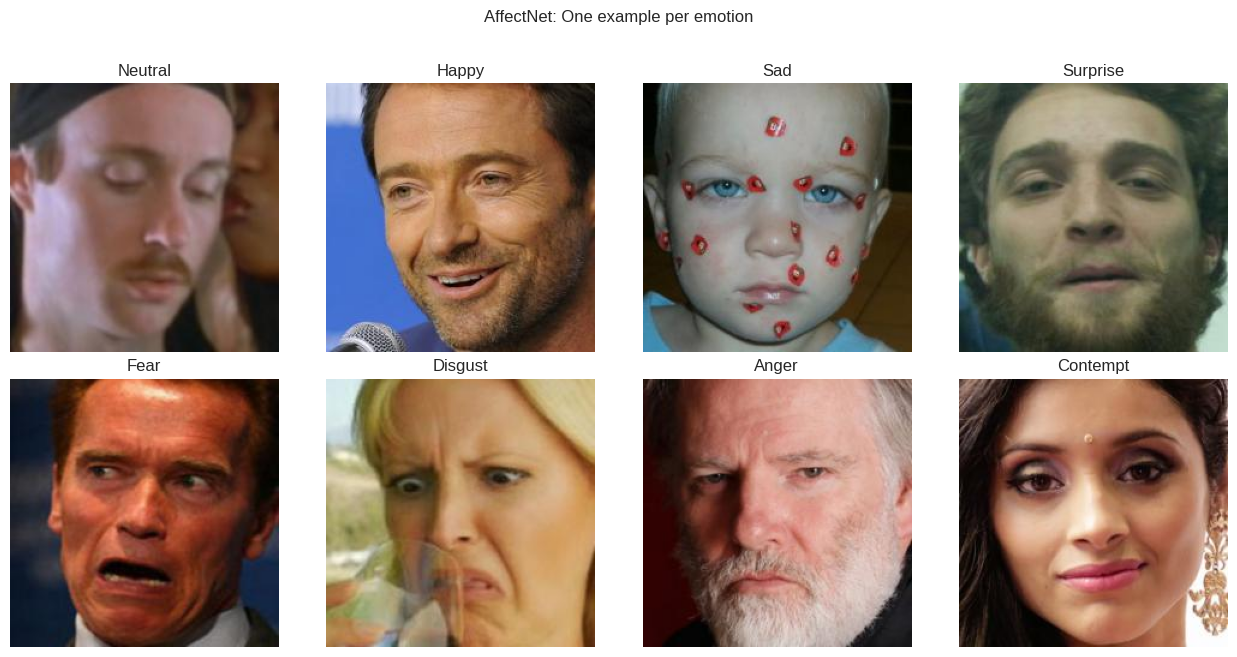

Saved: /home/ichalalentarek/Desktop/Deep Learning/code/images_examples.png


In [9]:
# Display and save one example image per emotion (4 per row)
# Uses train_ds if available, otherwise falls back to val_ds

# Select dataset
selected_ds = None
if 'train_ds' in globals():
    selected_ds = train_ds
elif 'val_ds' in globals():
    selected_ds = val_ds

if selected_ds is None:
    print('No dataset available (train_ds/val_ds not found).')
else:
    image_dir = getattr(selected_ds, 'image_dir', None)
    annotations = getattr(selected_ds, 'annotations', None)

    if not image_dir or not os.path.isdir(image_dir):
        print(f'Invalid image_dir: {image_dir}')
    elif not isinstance(annotations, dict) or len(annotations) == 0:
        print('No annotations found on selected dataset.')
    else:
        # Index available image files by base id (filename without extension)
        filename_by_id = {}
        try:
            for fname in os.listdir(image_dir):
                base, ext = os.path.splitext(fname)
                if ext.lower() in IMAGE_EXTENSIONS and base not in filename_by_id:
                    filename_by_id[base] = fname
        except Exception as e:
            print('Failed to scan image directory:', e)
            filename_by_id = {}

        # Find one example path for each emotion id
        example_path_by_emotion = {}
        for key, value in annotations.items():
            if not isinstance(key, str) or not key.endswith('_exp'):
                continue
            base_id = key[:-4]  # strip suffix '_exp'
            try:
                label_value = _to_scalar(value)
                emotion_id = int(label_value)
            except Exception:
                continue

            if emotion_id not in EMOTION_NAMES:
                continue
            if emotion_id in example_path_by_emotion:
                continue

            fname = filename_by_id.get(base_id)
            if not fname:
                continue

            full_path = os.path.join(image_dir, fname)
            if os.path.exists(full_path):
                example_path_by_emotion[emotion_id] = full_path

            if len(example_path_by_emotion) == len(EMOTION_NAMES):
                break

        if len(example_path_by_emotion) == 0:
            print('Could not locate any example images for emotions.')
        else:
            # Order emotions by id 0..7 (or whatever is defined)
            ordered_emotions = [eid for eid in sorted(EMOTION_NAMES.keys()) if eid in example_path_by_emotion]
            num_examples = len(ordered_emotions)

            cols = 4
            rows = math.ceil(num_examples / cols)
            fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))

            # Ensure axes is a 2D array
            if rows == 1:
                axes = np.array([axes])
            if cols == 1:
                axes = axes.reshape(rows, 1)

            for idx in range(rows * cols):
                r = idx // cols
                c = idx % cols
                ax = axes[r, c]
                if idx < num_examples:
                    emotion_id = ordered_emotions[idx]
                    img_path = example_path_by_emotion[emotion_id]
                    try:
                        with Image.open(img_path) as im:
                            ax.imshow(im)
                    except Exception:
                        ax.text(0.5, 0.5, 'Load error', ha='center', va='center')
                    ax.set_title(EMOTION_NAMES.get(emotion_id, str(emotion_id)))
                    ax.axis('off')
                else:
                    ax.axis('off')

            fig.suptitle('AffectNet: One example per emotion', y=1.02)
            fig.tight_layout()

            out_path = os.path.join(OUTPUT_DIR, 'images_examples.png')
            fig.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)
            print(f'Saved: {out_path}')
